# 01 - Exploratory Data Analysis
### Delivery Risk Dashboard & AI Agent — Business Intelligence Capstone

This notebook is optional and exploratory. **All production code lives in
`src/`** (`data_preprocessing.py`, `train_model.py`) and does not depend on
this notebook running. Use this notebook to explore the data interactively,
generate extra charts for your report, or test ideas before (optionally)
proposing changes to `src/`.

Dataset: DataCo Smart Supply Chain for Big Data Analysis (180,519 real orders).


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (8, 5)


## 1. Load raw data

In [2]:
RAW = os.path.join('..', 'data', 'raw', 'DataCoSupplyChainDataset.csv')
SAMPLE = os.path.join('..', 'data', 'sample', 'DataCoSupplyChain_sample.csv')
path = RAW if os.path.exists(RAW) else SAMPLE
df = pd.read_csv(path, encoding='ISO-8859-1')
print(path)
df.shape

../data/raw/DataCoSupplyChainDataset.csv


(180519, 53)

In [3]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## 2. Missing values & basic stats

In [4]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64

In [5]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


## 3. Delivery performance overview

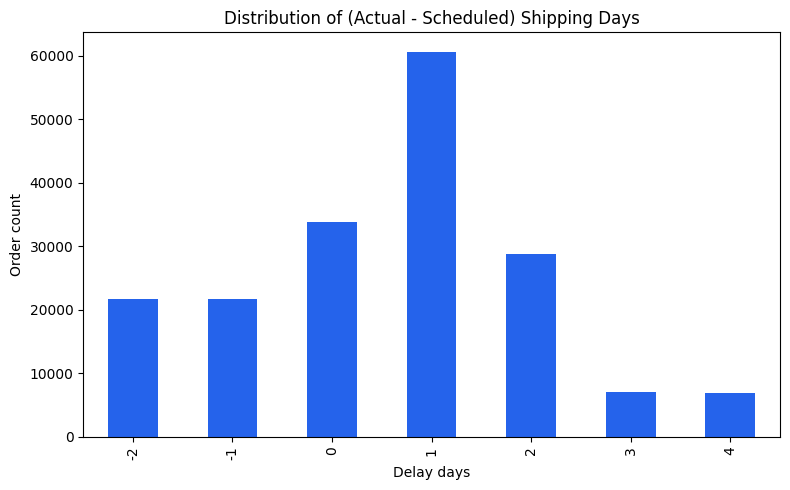

In [6]:
delay_days = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
ax = delay_days.value_counts().sort_index().plot(kind='bar', color='#2563eb')
ax.set_title('Distribution of (Actual - Scheduled) Shipping Days')
ax.set_xlabel('Delay days')
ax.set_ylabel('Order count')
plt.tight_layout()
plt.show()

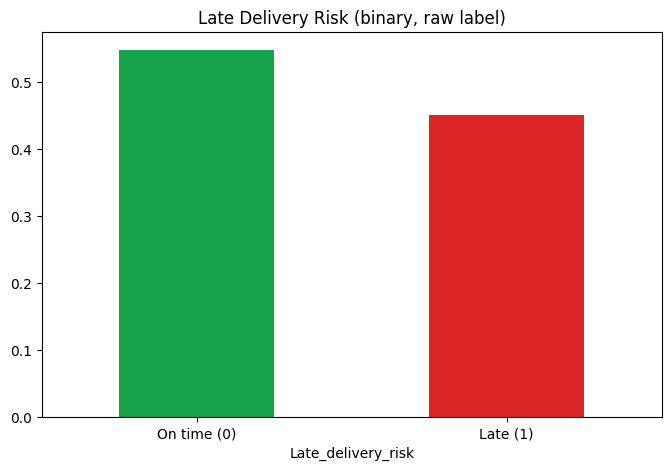

In [7]:
df['Late_delivery_risk'].value_counts(normalize=True).plot(
    kind='bar', color=['#16a34a', '#dc2626'], title='Late Delivery Risk (binary, raw label)'
)
plt.xticks([0, 1], ['On time (0)', 'Late (1)'], rotation=0)
plt.show()

## 4. Delivery risk by Shipping Mode and Region

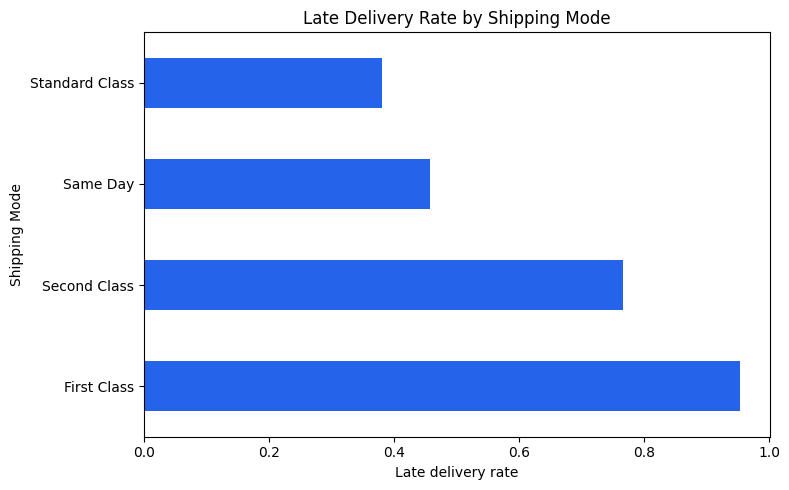

In [8]:
mode_risk = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending=False)
mode_risk.plot(kind='barh', color='#2563eb', title='Late Delivery Rate by Shipping Mode')
plt.xlabel('Late delivery rate')
plt.tight_layout()
plt.show()

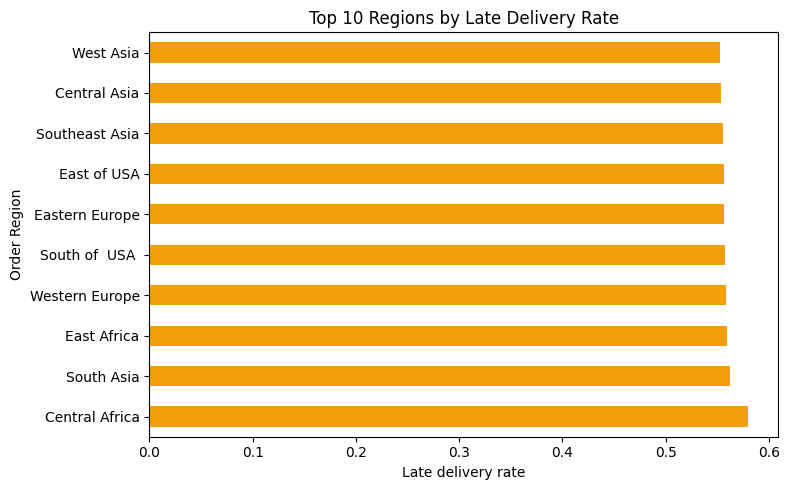

In [9]:
region_risk = df.groupby('Order Region')['Late_delivery_risk'].mean().sort_values(ascending=False).head(10)
region_risk.plot(kind='barh', color='#f59e0b', title='Top 10 Regions by Late Delivery Rate')
plt.xlabel('Late delivery rate')
plt.tight_layout()
plt.show()

## 5. Correlation matrix (numeric features)

This mirrors the correlation heatmap used in the reference stockout-risk
project's EDA step.

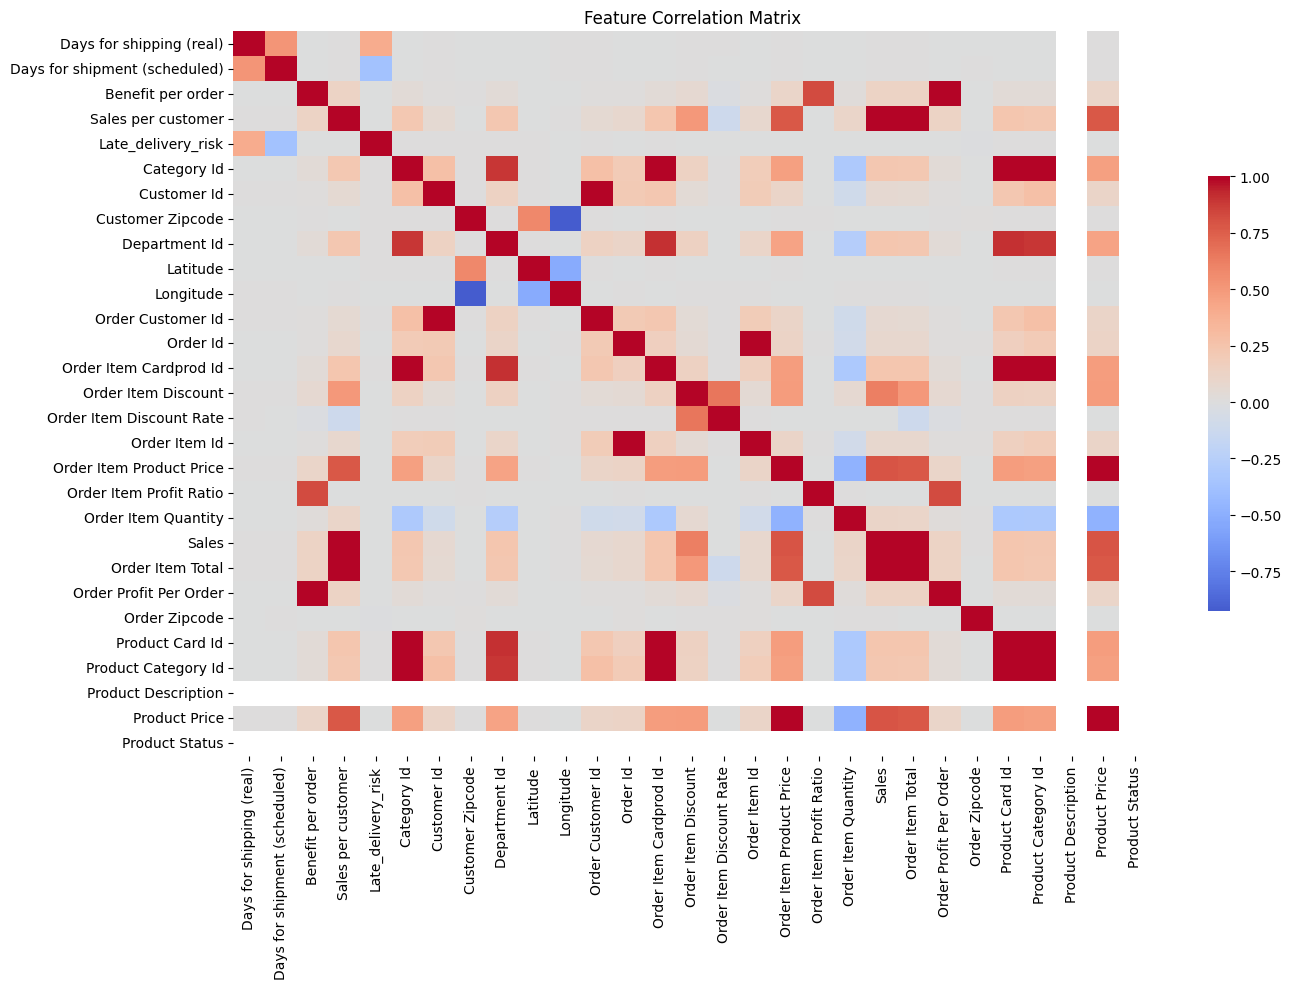

In [10]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, cbar_kws={'shrink': 0.6})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 6. Next steps

The production pipeline (`src/data_preprocessing.py` and `src/train_model.py`)
takes these observations further: it engineers the 3-class
`Delivery_Risk_Category` target, removes leakage/PII columns, and trains four
models to predict it. Run:

```bash
python ../src/data_preprocessing.py
python ../src/train_model.py
```

from the project root to reproduce the full pipeline outputs used by the
dashboard.
